# Example of training NN with attention with history

## Dataset exploration

- Data was prepared beforehand using Rust for speed and utilizing CPU
- Results were pushed to github in order to skip data preprocessing in notebook in case it opens in Google Colab

In [ ]:
!sudo apt install aria2c
!aria2c https://zenodo.org/api/records/56198/files-archive

In [ ]:
# !curl https://zenodo.org/api/records/56198/files-archive --output 56198.zip

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  292M    0  292M    0     0  1645k      0 --:--:--  0:03:02 --:--:-- 2434k  0     0  1464k      0 --:--:--  0:00:46 --:--:-- 1532k21k      0 --:--:--  0:01:30 --:--:-- 1965k


In [ ]:
!unzip 56198.zip

In [ ]:
!git clone https://github.com/misssglory/parse-latex

In [ ]:
!mv parse-latex/* . && ls

In [19]:
!cat README.md

4678.70s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


# Translate Latex from images to formula

- [Paper](https://arxiv.org/pdf/1609.04938)


## Dataset preprocess stage

- [Dataset link](https://zenodo.org/records/56198#.V2p0KTXT6eA) 
- Scripts crop images to least common union rectangle and convert to 1-channel format in order to save disk space
- Rust is used in order to preprocess with CPU multithreading

```bash
# Consider dataset is in dataset folder
cd dataset
unzip 56198.zip
tar -xvf formula_images.tar.gz
rm 56198.zip
rm formula_images.tar.gz
cd -
mkdir -p dataset/crop
mkdir -p dataset/formatted
cargo run --release --bin crop_union_formulas -- dataset/formula_images dataset/crop
cargo run --release --bin change_format -- dataset/crop dataset/formatted
rm -r dataset/crop
rm -r dataset/formula_images
```

## Nix environment setup for ROCm (incomplete)
```
nix build .#rocm-cmake
nix build .#libdivide
nix build .#hipsparselt
...
```



## Starting input prompt
```
here is paper to implement image to text attention model for latex form

In [ ]:
!mv parse-latex/.git . || mv parse-latex/.gitignore . || git pull origin main

In [ ]:
!pip install uv && uv venv && . .venv/bin/activate

In [ ]:
!uv pip install -r requirements.txt

In [26]:
!cat configs/fp16.json

6646.39s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


{
  "dataset_dir": "dataset",
  "output_dir": "outputs_fp16",
  "epochs": 20,
  "batch_size": 12,
  "lr": 0.001,
  "seed": 42,
  "max_len": 160,
  "vocab_size": 1800,
  "min_freq": 1,
  "target_height": 128,
  "max_width": 512,
  "scale_factor": 4.0,
  "d_model": 256,
  "emb_dim": 128,
  "dec_dim": 256,
  "attn_dim": 512,
  "visualize_every": 1,
  "precision": "fp16",
  "run_eagerly": false,
  "num_visual_samples": 3,
  "log_file": "train.log"
}

## Example of training with config parameters overriding

- After training it is possible to watch serialized logs and history
- Look into folder specified as `output_dir` in config json or just grep (`rg resolved_config.json`) for path

In [ ]:
!python train.py --config configs/fp16.json --batch-size 16 --scale-factor 1

I0000 00:00:1774091958.170569   14228 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1774091958.177277   14228 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1774091958.848954   14228 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1774091960.024657   14228 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

In [34]:
!python train.py --config configs/fp16_from32.json --batch-size 16 --scale-factor 1.0

12272.58s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


I0000 00:00:1774139941.727160  235014 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1774139941.727472  235014 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1774139941.774744  235014 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1774139943.192812  235014 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONE

## Example for continuing of training
- Training attention mechanism may be tedius
- This project is aimed to evaluate performance of ROCm setup for cheap hardware with lots of RAM, so this is quite useful

In [36]:
!python train.py --resume-from outputs_fp16 --epochs 1

12316.68s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


I0000 00:00:1774139985.814664  235177 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1774139985.814970  235177 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1774139985.861643  235177 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1774139987.143861  235177 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONE

## Loading of trained model and visualization of attention map

In [22]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from config import TrainConfig
from data import load_formulas, load_split, Vocab, preprocess_image
from model import Im2LatexModel
from metrics import char_diff, compile_latex_formula
from utils import setup_precision, set_seed


# 1) Load config and setup
cfg_path = "outputs_fp16_small/resolved_config.json"
cfg = TrainConfig.load_json(cfg_path)
cfg.output_dir = "outputs_fp16_small"  # ensure correct path

# 2) Load formulas + test split
formulas = load_formulas(os.path.join(cfg.dataset_dir, "im2latex_formulas.lst"))
test_samples = load_split(
    os.path.join(cfg.dataset_dir, "im2latex_test.lst"),
    formulas,
    os.path.join(cfg.dataset_dir, "formatted"),
)

# 3) Load vocab
vocab = Vocab.load(os.path.join(cfg.output_dir, "vocab.json"))

# 4) Build model and load weights
setup_precision(cfg.precision)
set_seed(cfg.seed)

model = Im2LatexModel(
    vocab_size=len(vocab.token_to_id),
    d_model=cfg.d_model,
    emb_dim=cfg.emb_dim,
    dec_dim=cfg.dec_dim,
    attn_dim=cfg.attn_dim,
    bos_id=vocab.bos_id,
    eos_id=vocab.eos_id,
    pad_id=vocab.pad_id,
    name="im2_latex_model",
)

dummy_images = tf.zeros([1, cfg.target_height, 128, 1], dtype=tf.float32)
dummy_tgt = tf.zeros([1, cfg.max_len - 1], dtype=tf.int32)
_ = model((dummy_images, dummy_tgt), training=False)

best_ckpt = os.path.join(cfg.output_dir, "checkpoints", "best.weights.h5")
model.load_weights(best_ckpt)
print("Loaded:", best_ckpt)

2026-03-22 01:54:39.599 | WARNING  | data:read_text_auto:92 - Failed reading dataset/im2latex_formulas.lst with encoding=utf-8: 'utf-8' codec can't decode byte 0xe7 in position 854136: invalid continuation byte
2026-03-22 01:54:39.679 | WARNING  | data:read_text_auto:92 - Failed reading dataset/im2latex_formulas.lst with encoding=utf-8-sig: 'utf-8' codec can't decode byte 0xe7 in position 854136: invalid continuation byte
2026-03-22 01:54:39.760 | INFO     | data:read_text_auto:88 - Read dataset/im2latex_formulas.lst with encoding=cp1252
2026-03-22 01:54:39.807 | INFO     | data:load_formulas:100 - Loaded 104564 formulas from dataset/im2latex_formulas.lst using encoding=cp1252
2026-03-22 01:54:39.948 | INFO     | utils:setup_precision:31 - Mixed precision policy set to <DTypePolicy "mixed_float16">
2026-03-22 01:54:39.949 | WARNING  | utils:setup_precision:33 - fp16 selected but no GPU detected; on CPU this may be slower.
/home/mg/gh/cp-parse-latex/.venv/lib/python3.12/site-packages/ke

Loaded: outputs_fp16_small/checkpoints/best.weights.h5


In [4]:
test_samples

[{'image_path': 'dataset/formatted/7944775fc9.png',
  'formula': 'i\\Delta ^{ab}(q)=\\frac{-i\\delta ^{ab}}{q^2-\\mu ^2+i\\varepsilon }',
  'render_type': 'basic'},
 {'image_path': 'dataset/formatted/78228211ca.png',
  'formula': '{\\cal A}_{n} : = \\langle \\prod_{j=1}^{m} S^{k_j}_{-l_j} |\\sum_{j=1}^{m} l_j \\geq n \\rangle\\,,',
  'render_type': 'basic'},
 {'image_path': 'dataset/formatted/15b9034ba8.png',
  'formula': '\\label{fierep}P_{(2)}^-=\\int \\beta d\\beta d^9p d^8\\lambda \\Phi(-p,-\\lambda)\\left(-\\frac{p^Ip^I}{2\\beta}\\right) \\Phi(p,\\lambda)\\,.',
  'render_type': 'basic'},
 {'image_path': 'dataset/formatted/6968dfca15.png',
  'formula': '{\\bf E} \\rightarrow - c {{\\bf B}^{\\prime}}\\hspace{1.0in}   c {\\bf B} \\rightarrow {{\\bf E}^{\\prime}}',
  'render_type': 'basic'},
 {'image_path': 'dataset/formatted/6cead0df53.png',
  'formula': 'a^{2}=\\frac{m\\mu }{k^{2}e\\lambda ^{2}_{\\phi }}\\, .',
  'render_type': 'basic'},
 {'image_path': 'dataset/formatted/5381b22df4

In [23]:
import cv2
from viz import overlay_attention  # if you have viz.py; otherwise copy overlayAttention code here


def visualize_samples_inline(sample_indices, max_len=None):
    if max_len is None:
        max_len = cfg.max_len - 1

    n = len(sample_indices)
    plt.figure(figsize=(10, 3 * n))

    for i, idx in enumerate(sample_indices):
        sample = test_samples[idx]
        img = preprocess_image(
            sample["image_path"],
            target_height=cfg.target_height,
            max_width=cfg.max_width,
            scale_factor=cfg.scale_factor,
        )

        batch = tf.convert_to_tensor(img[None, ...], dtype=tf.float32)
        pred_ids, attn = model.greedy_decode(batch, max_len=max_len)

        pred_formula = vocab.decode(pred_ids[0].numpy())
        gt_formula = sample["formula"]
        avg_attn = tf.reduce_mean(attn[0], axis=0).numpy()
        compiles, _ = compile_latex_formula(pred_formula)
        diff = char_diff(gt_formula, pred_formula)

        blended = overlay_attention(img, avg_attn)

        ax = plt.subplot(n, 1, i + 1)
        ax.imshow(blended)
        ax.set_title(
            f"idx={idx}  COMPILES: {compiles}\n"
            f"GT:   {gt_formula}\n"
            f"PRED: {pred_formula}\n"
            f"DIFF: {diff}",
            fontsize=8
        )
        ax.axis("off")

    plt.tight_layout()
    plt.show()

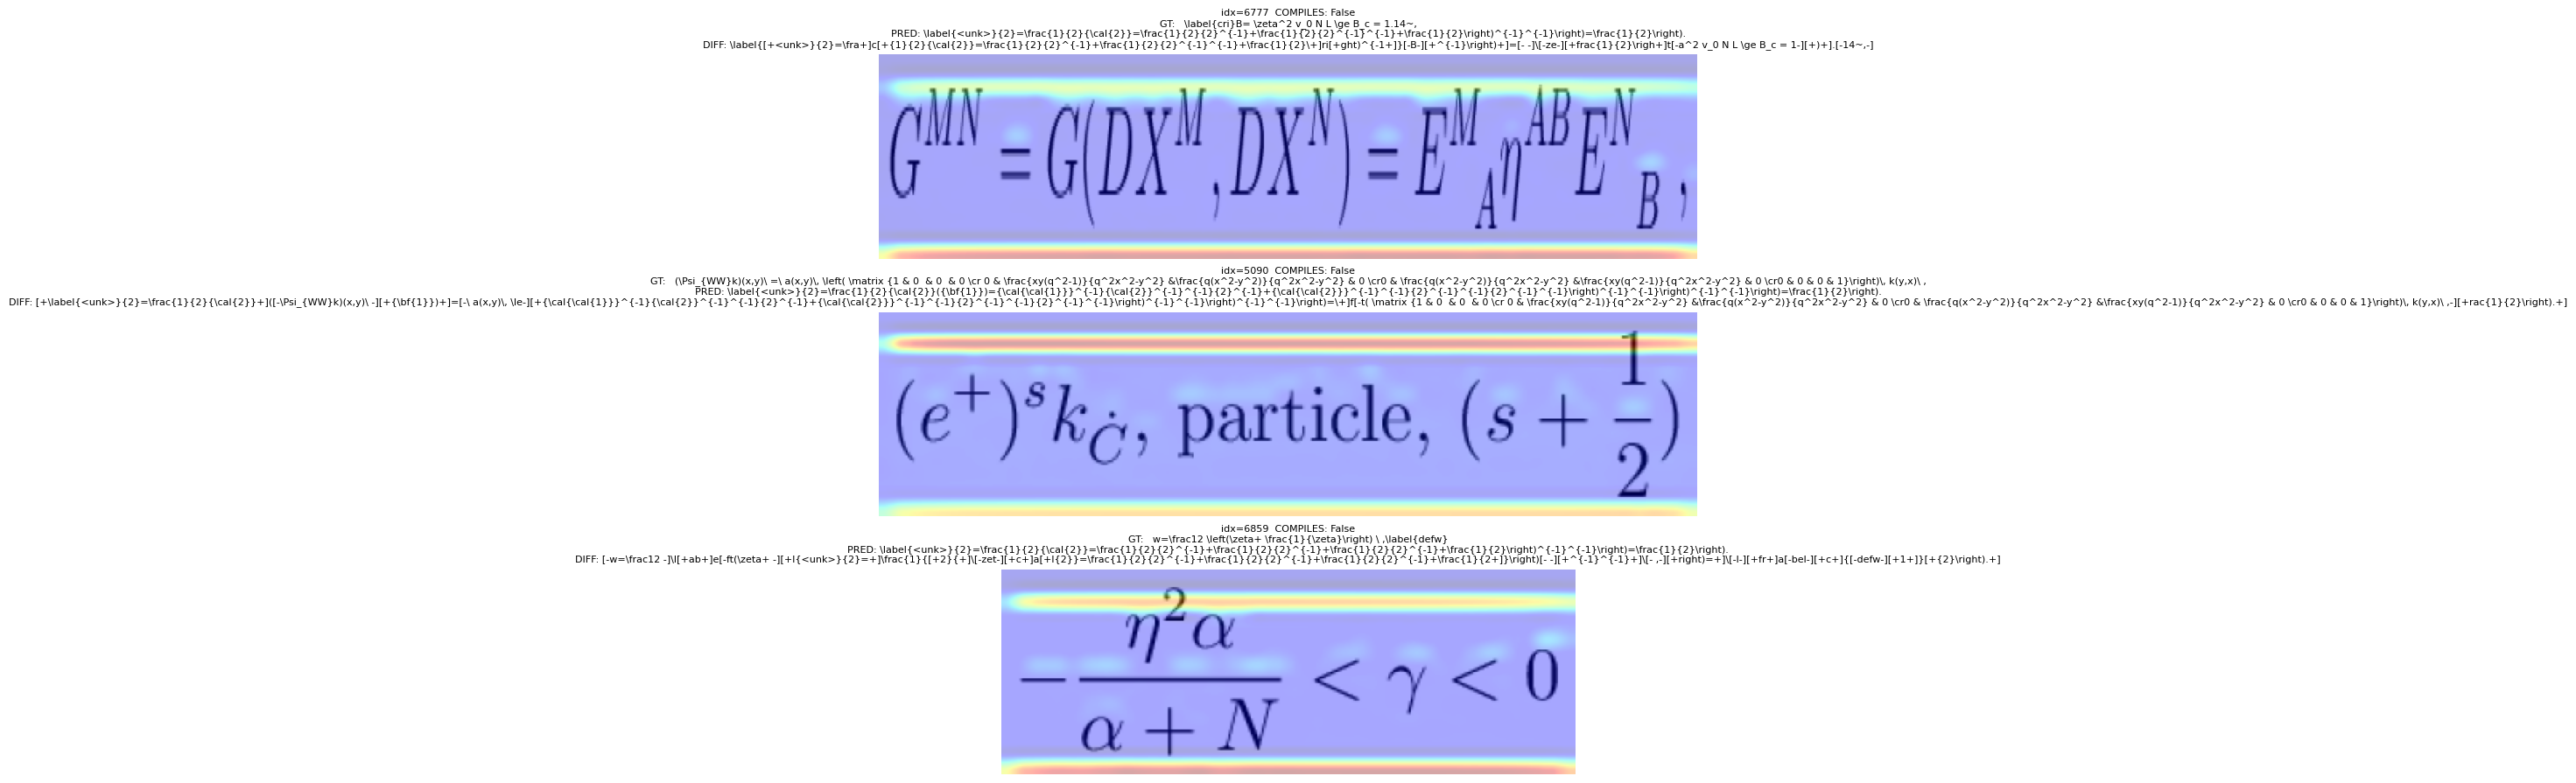

In [24]:
np.random.seed(0)
indices = np.random.choice(len(test_samples), size=3, replace=False)
visualize_samples_inline(indices)


In [7]:
model.summary()

Model: "im2_latex_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ cnn_encoder (CNNEncoder)        │ ?                      │     2,144,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ row_encoder (RowEncoder)        │ ?                      │       362,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder (AttentionDecoder)      │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,571,233 (13.62 MB)

 Trainable params: 3,568,801 (13.61 MB)

 Non-trainable params: 2,432 (9.50 KB)

## Examine saved vocabulary and training history

In [ ]:
# !apt intsall batcat
!cat outputs_fp16_small/vocab.json

6223.57s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


{
  "<pad>": 0,
  "<bos>": 1,
  "<eos>": 2,
  "<unk>": 3,
  "{": 4,
  "}": 5,
  "_": 6,
  "^": 7,
  ")": 8,
  "(": 9,
  "2": 10,
  "-": 11,
  "1": 12,
  "=": 13,
  ",": 14,
  "+": 15,
  "\\frac": 16,
  "0": 17,
  ".": 18,
  "\\label": 19,
  "i": 20,
  "\\,": 21,
  "x": 22,
  "\\mu": 23,
  "\\left": 24,
  "\\right": 25,
  "a": 26,
  "n": 27,
  "&": 28,
  "k": 29,
  "3": 30,
  "\\alpha": 31,
  "\\partial": 32,
  "4": 33,
  "\\;": 34,
  "d": 35,
  "m": 36,
  "A": 37,
  "]": 38,
  "[": 39,
  "p": 40,
  "~": 41,
  "\\over": 42,
  "e": 43,
  "\\nu": 44,
  "|": 45,
  "\\pi": 46,
  "\\ ": 47,
  "r": 48,
  "z": 49,
  "\\phi": 50,
  "'": 51,
  "j": 52,
  "g": 53,
  "\\cal": 54,
  "\\delta": 55,
  "t": 56,
  "\\lambda": 57,
  "q": 58,
  "\\beta": 59,
  "\\int": 60,
  "\\bar": 61,
  "N": 62,
  "c": 63,
  "b": 64,
  "R": 65,
  "\\theta": 66,
  "D": 67,
  "\\sigma": 68,
  "L": 69,
  "/": 70,
  "array": 71,
  "\\\\": 72,
  "F": 73,
  "\\gamma": 74,
  "f": 75,
  "M": 76,
  "S": 77,
  "\\hat": 78,
  "T

In [ ]:
import matplotlib as plt

plt.imshow("outputs_fp16_small/history.png")
plt.show()